<a href="https://colab.research.google.com/github/Phuc1Le/pyTorch-from-scratch/blob/main/simple_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [50]:
class my_model(nn.Module):
  def __init__(self, in_features=4, h1=8, h2=8, output=3):
    super().__init__() # instantiate nn.Module
    self.fc1 = nn.Linear(in_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2, output)
  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)
    return x


In [51]:
torch.manual_seed(41)
model = my_model()

In [52]:
import matplotlib.pyplot as plt
%matplotlib inline

In [53]:
import pandas as pd

In [54]:
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
my_df = pd.read_csv(url)
my_df[:5]

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [55]:
my_df['variety'] = my_df['variety'].replace('Setosa', 0.0)
my_df['variety'] = my_df['variety'].replace('Versicolor', 1.0)
my_df['variety'] = my_df['variety'].replace('Virginica', 2.0)
my_df[:5]

/tmp/ipykernel_1799/3534255138.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['variety'] = my_df['variety'].replace('Virginica', 2.0)


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


In [56]:
X = my_df.drop('variety', axis=1)
y = my_df['variety']

In [57]:
X = X.values
y = y.values

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [60]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [61]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [62]:
epochs = 100
loss = []
for i in range(epochs):
  y_pred = model.forward(X_train)
  loss_val = criterion(y_pred, y_train)
  loss.append(loss_val.detach().numpy())
  if i%10 == 0:
    print(f'Epoch: {i} Loss: {loss_val}')
  optimizer.zero_grad()
  loss_val.backward()
  optimizer.step()

Epoch: 0 Loss: 1.1318365335464478
Epoch: 10 Loss: 0.9658561944961548
Epoch: 20 Loss: 0.6789938807487488
Epoch: 30 Loss: 0.4004894495010376
Epoch: 40 Loss: 0.22509503364562988
Epoch: 50 Loss: 0.12207334488630295
Epoch: 60 Loss: 0.07481689006090164
Epoch: 70 Loss: 0.054512783885002136
Epoch: 80 Loss: 0.04437492415308952
Epoch: 90 Loss: 0.03837944194674492


Text(0.5, 0, 'Epochs')

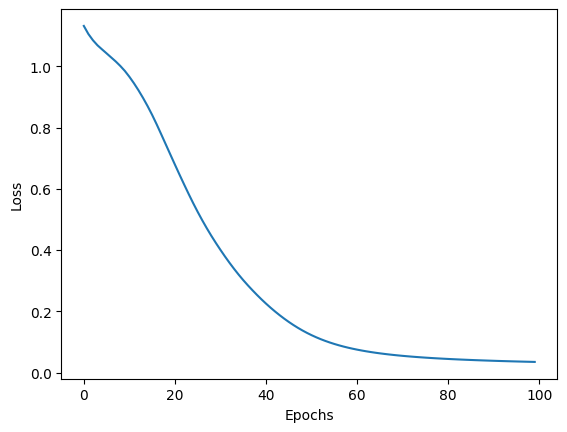

In [63]:
plt.plot(range(epochs), loss)
plt.ylabel('Loss')
plt.xlabel('Epochs')
#

In [68]:
with torch.no_grad():
  y_eval = model.forward(X_test)
  loss_val = criterion(y_eval, y_test)
loss_val

tensor(0.1458)

In [67]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)
    if y_val.argmax().item() == y_test[i]:
      correct += 1
print(correct)

29


In [69]:
new_iris = torch.tensor([4.7, 3.2, 1.3, 0.2])
with torch.no_grad():
  print(model(new_iris))

tensor([  9.2092,   3.0850, -18.2915])


In [70]:
torch.save(model.state_dict(), 'iris_model.pt')

In [71]:
new_model = my_model()
new_model.load_state_dict(torch.load('iris_model.pt'))

<All keys matched successfully>

In [72]:
new_model.eval()

my_model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=8, bias=True)
  (out): Linear(in_features=8, out_features=3, bias=True)
)